# Project 1: Exploratory Data Analysis of Customer Transactions

## Learning objective

Raw transaction tables are common in retail, e-commerce, banking, and subscription businesses. The objective of this project is to convert transaction-level records into reliable business summaries and customer-level insights.

The main workflow is:

1. inspect the raw data structure,
2. identify missing values, duplicates, cancellations, and invalid transactions,
3. create revenue-based metrics,
4. analyze products, customers, countries, and time trends,
5. convert transaction history into RFM customer features,
6. create interpretable customer segments.

The emphasis is on structured reasoning. EDA is not only plotting; it is the process of checking whether the data is suitable for the business question being asked.


## Prerequisites

The notebook assumes familiarity with basic Python, pandas, NumPy, and plotting. Some later sections use simple feature scaling and K-Means clustering, but the clustering section is exploratory and can be skipped without breaking the main EDA flow.


## Problem statement

Given raw transaction-level retail data, analyze sales patterns, customer behavior, product importance, country-wise contribution, temporal patterns, and customer value segments.

A realistic transaction dataset contains operational complications: missing customer identifiers, cancelled invoices, duplicate-looking records, extreme quantities, and highly skewed revenue. These issues must be studied before drawing business conclusions.


## Dataset description and source

The project uses the **UCI Online Retail dataset**, which contains transactions from a UK-based online retail business between December 2010 and December 2011.

Main columns:

| Column | Meaning |
|---|---|
| `InvoiceNo` | Invoice number. Values starting with `C` usually indicate cancellations. |
| `StockCode` | Product/item code. |
| `Description` | Product description. |
| `Quantity` | Number of units in the invoice line. Negative values often indicate returns/cancellations. |
| `InvoiceDate` | Date and time of transaction. |
| `UnitPrice` | Price per unit. |
| `CustomerID` | Customer identifier. Missing values limit customer-level analysis. |
| `Country` | Customer country. |

The dataset is loaded directly from the UCI repository using Python. No local Excel file is required.


In [ ]:
# Optional installation cell. Uncomment if running in a fresh environment.
# !pip install pandas numpy matplotlib seaborn scikit-learn openpyxl requests


## Load required libraries

The first group of libraries handles data manipulation and visualization. Scikit-learn is used only for the optional customer segmentation section.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from urllib.request import urlretrieve

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


## Load dataset directly using Python

The Excel file is downloaded temporarily into the notebook runtime and then read with `pandas.read_excel`. This keeps the workflow reproducible without relying on a manually downloaded file.


In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
local_path = Path("online_retail_uci.xlsx")

if not local_path.exists():
    print("Downloading Online Retail dataset from UCI...")
    urlretrieve(url, local_path)

raw_df = pd.read_excel(local_path, engine="openpyxl")
print("Shape:", raw_df.shape)
display(raw_df.head())


Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.550,"17,850.000",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.390,"17,850.000",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.750,"17,850.000",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.390,"17,850.000",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.390,"17,850.000",United Kingdom


## Initial data inspection

Before cleaning, inspect the size, column types, and basic counts. In transaction data, each row is usually an invoice line, not a full order or a unique customer.


In [3]:
df = raw_df.copy()

print("Data types and non-null counts:")
display(df.info())

print("\nNumerical summary:")
display(df.describe())

summary_counts = pd.Series({
    "unique_invoices": df["InvoiceNo"].nunique(),
    "unique_products": df["StockCode"].nunique(),
    "unique_customers": df["CustomerID"].nunique(dropna=True),
    "unique_countries": df["Country"].nunique(),
    "start_date": df["InvoiceDate"].min(),
    "end_date": df["InvoiceDate"].max()
})
display(summary_counts)


Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


None


Numerical summary:


,Quantity,UnitPrice,CustomerID
count,"541,909.000","541,909.000","406,829.000"
mean,9.552,4.611,"15,287.691"
std,218.081,96.760,"1,713.600"
min,"-80,995.000","-11,062.060","12,346.000"
25%,1.000,1.250,"13,953.000"
50%,3.000,2.080,"15,152.000"
75%,10.000,4.130,"16,791.000"
max,"80,995.000","38,970.000","18,287.000"


unique_invoices                   25900
unique_products                    4070
unique_customers                   4372
unique_countries                     38
start_date          2010-12-01 08:26:00
end_date            2011-12-09 12:50:00
dtype: object

### Interpretation guide

After running the inspection cells, check whether the table represents invoice lines, whether the date range matches the expected period, and which columns have missing values. Large differences between the number of rows, invoices, and customers are normal in transaction data.


## Missing value analysis

Missing values have different meanings depending on the column. A missing product description may affect product naming, but a missing `CustomerID` prevents customer-level analysis such as RFM scoring.


,missing_count,missing_percent
CustomerID,135080,24.927
Description,1454,0.268
InvoiceNo,0,0.000
StockCode,0,0.000
Quantity,0,0.000
InvoiceDate,0,0.000
UnitPrice,0,0.000
Country,0,0.000


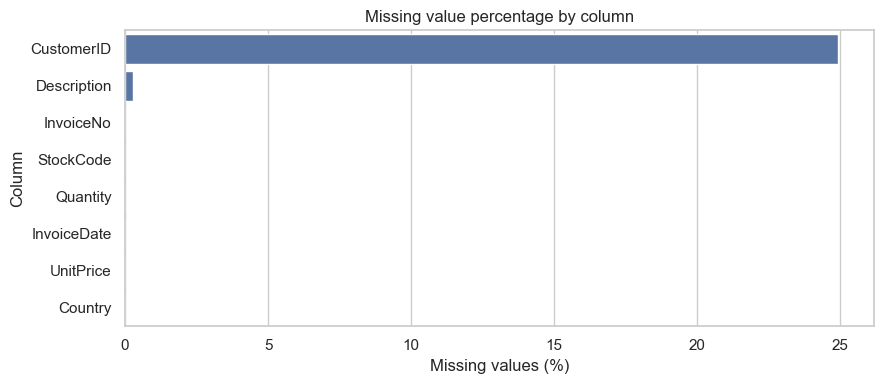

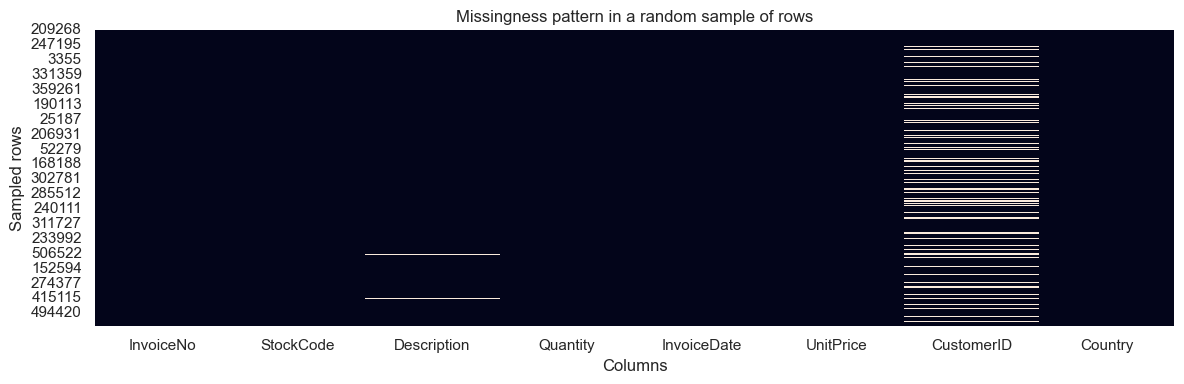

In [4]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": 100 * df.isna().mean()
}).sort_values("missing_percent", ascending=False)

display(missing)

plt.figure(figsize=(9, 4))
sns.barplot(data=missing.reset_index(), x="missing_percent", y="index")
plt.xlabel("Missing values (%)")
plt.ylabel("Column")
plt.title("Missing value percentage by column")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
sns.heatmap(df.sample(min(3000, len(df)), random_state=RANDOM_STATE).isna(), cbar=False)
plt.title("Missingness pattern in a random sample of rows")
plt.xlabel("Columns")
plt.ylabel("Sampled rows")
plt.tight_layout()
plt.show()


### Interpretation guide

Observe which columns have substantial missingness. If `CustomerID` is missing for many rows, product-level and revenue-level EDA can still be done, but customer-level analysis should use only valid customer identifiers. Missingness should not be silently ignored because it changes the population being analyzed.


## Duplicate transaction analysis

Repeated rows may be accidental duplicates, but they can also represent valid repeated purchases of the same item. The count and examples are inspected before deciding how to clean them.


In [5]:
duplicate_count = df.duplicated().sum()
print("Exact duplicate rows:", duplicate_count)

if duplicate_count > 0:
    display(df[df.duplicated(keep=False)].sort_values(list(df.columns)).head(10))

# Conservative cleaning choice: remove exact duplicate rows only.
df_no_duplicates = df.drop_duplicates().copy()
print("Shape before removing exact duplicates:", df.shape)
print("Shape after removing exact duplicates:", df_no_duplicates.shape)


Exact duplicate rows: 5268


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.250,"17,908.000",United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.250,"17,908.000",United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.950,"17,908.000",United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.950,"17,908.000",United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.100,"17,908.000",United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.100,"17,908.000",United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.950,"17,908.000",United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.950,"17,908.000",United Kingdom
578,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.650,"17,920.000",United Kingdom
598,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.650,"17,920.000",United Kingdom


Shape before removing exact duplicates: (541909, 8)
Shape after removing exact duplicates: (536641, 8)


### Interpretation guide

If exact duplicates exist, compare their frequency with the full dataset size. Removing exact duplicates is usually safer than removing records that only share invoice and product identifiers, because a customer may legitimately buy the same product multiple times.


## Cancelled orders and invalid transactions

The Online Retail dataset contains cancellations and returns. These records are important for operational analysis, but they can distort gross sales and customer purchase summaries if mixed with completed sales.

For the main revenue analysis, a cleaned sales dataset is created by removing cancelled invoices, non-positive quantity, and non-positive unit price.


In [6]:
work_df = df_no_duplicates.copy()
work_df["InvoiceNo"] = work_df["InvoiceNo"].astype(str)

cancelled_mask = work_df["InvoiceNo"].str.startswith("C", na=False)
negative_quantity_mask = work_df["Quantity"] <= 0
nonpositive_price_mask = work_df["UnitPrice"] <= 0

quality_summary = pd.Series({
    "rows_after_duplicate_removal": len(work_df),
    "cancelled_invoice_rows": cancelled_mask.sum(),
    "non_positive_quantity_rows": negative_quantity_mask.sum(),
    "non_positive_unit_price_rows": nonpositive_price_mask.sum(),
    "rows_with_missing_customer_id": work_df["CustomerID"].isna().sum()
})
display(quality_summary)

clean_df = work_df.loc[
    (~cancelled_mask) &
    (work_df["Quantity"] > 0) &
    (work_df["UnitPrice"] > 0)
].copy()

cleaning_comparison = pd.DataFrame({
    "stage": ["raw", "after_exact_duplicate_removal", "after_sales_cleaning"],
    "rows": [len(df), len(work_df), len(clean_df)],
    "unique_invoices": [df["InvoiceNo"].astype(str).nunique(), work_df["InvoiceNo"].nunique(), clean_df["InvoiceNo"].nunique()],
    "unique_customers": [df["CustomerID"].nunique(dropna=True), work_df["CustomerID"].nunique(dropna=True), clean_df["CustomerID"].nunique(dropna=True)]
})
display(cleaning_comparison)


rows_after_duplicate_removal     536641
cancelled_invoice_rows             9251
non_positive_quantity_rows        10587
non_positive_unit_price_rows       2512
rows_with_missing_customer_id    135037
dtype: int64

,stage,rows,unique_invoices,unique_customers
0,raw,541909,25900,4372
1,after_exact_duplicate_removal,536641,25900,4372
2,after_sales_cleaning,524878,19960,4338


### Interpretation guide

Compare the row count before and after cleaning. A large reduction means that business conclusions should clearly state which transaction definition is being used: gross transactions, net transactions including returns, or completed positive sales only.


## Revenue calculation

For completed positive sales, line-level revenue is calculated as:

\[
	ext{Revenue} = 	ext{Quantity} 	imes 	ext{UnitPrice}
\]

This is sales revenue, not profit. The dataset does not include product cost, discounts, shipping charges, or marketing cost.


Total revenue: 10642110.804
Average line revenue: 20.27539886221179


count   524,878.000
mean         20.275
std         271.694
min           0.001
1%            0.550
5%            1.250
50%           9.920
95%          59.800
99%         183.600
max     168,469.600
Name: Revenue, dtype: float64

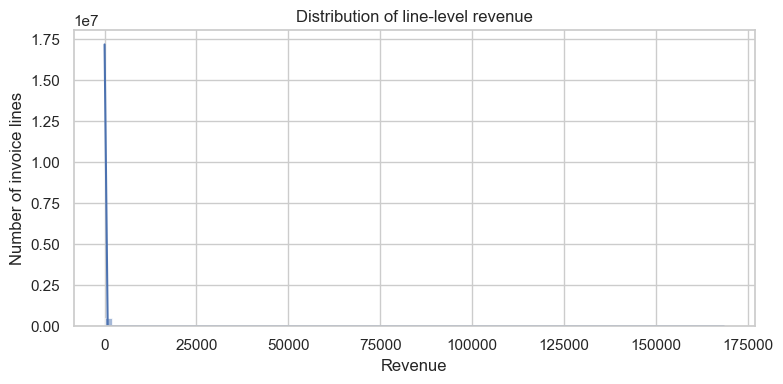

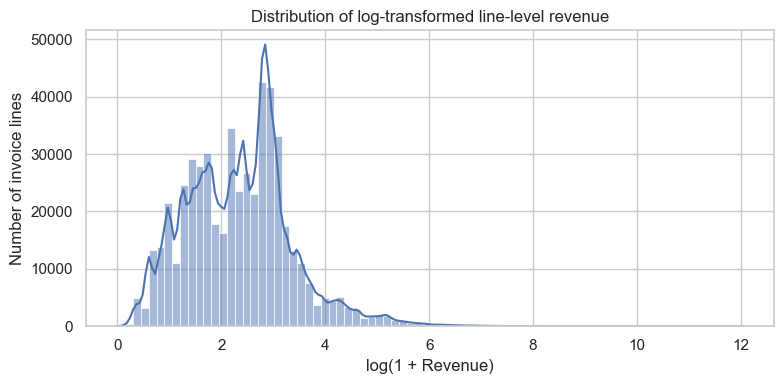

In [7]:
clean_df["Revenue"] = clean_df["Quantity"] * clean_df["UnitPrice"]

revenue_summary = clean_df["Revenue"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
print("Total revenue:", clean_df["Revenue"].sum())
print("Average line revenue:", clean_df["Revenue"].mean())
display(revenue_summary)

plt.figure(figsize=(8, 4))
sns.histplot(clean_df["Revenue"], bins=80, kde=True)
plt.title("Distribution of line-level revenue")
plt.xlabel("Revenue")
plt.ylabel("Number of invoice lines")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(np.log1p(clean_df["Revenue"]), bins=80, kde=True)
plt.title("Distribution of log-transformed line-level revenue")
plt.xlabel("log(1 + Revenue)")
plt.ylabel("Number of invoice lines")
plt.tight_layout()
plt.show()


### Interpretation guide

Transaction revenue is usually right-skewed. Compare the raw histogram with the log-transformed histogram. If the log plot is easier to read, this indicates that a small number of invoice lines are much larger than typical purchases.


## Outlier analysis

Outliers in transaction data are not automatically errors. A large quantity may be a wholesale order, and a high unit price may be a premium item. The decision to remove outliers depends on whether the analysis is about operational anomalies, typical customer behavior, or total revenue contribution.


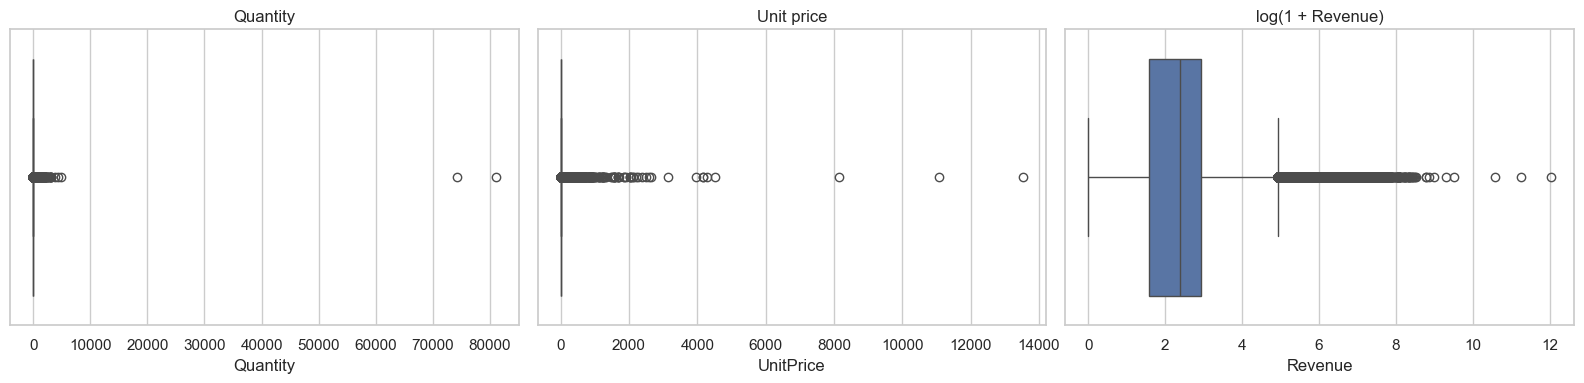

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Revenue,CustomerID,Country,InvoiceDate
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.080,"168,469.600","16,446.000",United Kingdom,2011-12-09 09:15:00
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.040,"77,183.600","12,346.000",United Kingdom,2011-01-18 10:01:00
222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,649.500,"38,970.000","15,098.000",United Kingdom,2011-06-10 15:28:00
15017,537632,AMAZONFEE,AMAZON FEE,1,"13,541.330","13,541.330",NaN,United Kingdom,2010-12-07 15:08:00
299982,A563185,B,Adjust bad debt,1,"11,062.060","11,062.060",NaN,United Kingdom,2011-08-12 14:50:00
173382,551697,POST,POSTAGE,1,"8,142.750","8,142.750","16,029.000",United Kingdom,2011-05-03 13:46:00
348325,567423,23243,SET OF TEA COFFEE SUGAR TINS PANTRY,1412,5.060,"7,144.720","17,450.000",United Kingdom,2011-09-20 11:05:00
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.100,"6,539.400","15,749.000",United Kingdom,2011-01-11 12:55:00
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.100,"6,539.400","15,749.000",United Kingdom,2011-04-18 13:20:00
421601,573003,23084,RABBIT NIGHT LIGHT,2400,2.080,"4,992.000","14,646.000",Netherlands,2011-10-27 12:11:00


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.boxplot(x=clean_df["Quantity"], ax=axes[0])
axes[0].set_title("Quantity")
sns.boxplot(x=clean_df["UnitPrice"], ax=axes[1])
axes[1].set_title("Unit price")
sns.boxplot(x=np.log1p(clean_df["Revenue"]), ax=axes[2])
axes[2].set_title("log(1 + Revenue)")
plt.tight_layout()
plt.show()

extreme_revenue = clean_df.sort_values("Revenue", ascending=False).head(10)
display(extreme_revenue[["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", "Revenue", "CustomerID", "Country", "InvoiceDate"]])


### Interpretation guide

Inspect the largest transactions rather than deleting them automatically. If top rows contain valid business purchases, they should usually be retained for revenue analysis but may be handled separately when modeling typical behavior.


## Product-level analysis

A product can be important in different ways: high quantity sold, high total revenue, or frequent occurrence across invoices. These rankings answer different business questions.


In [9]:
product_summary = clean_df.groupby(["StockCode", "Description"], dropna=False).agg(
    total_quantity=("Quantity", "sum"),
    total_revenue=("Revenue", "sum"),
    transaction_lines=("InvoiceNo", "count"),
    unique_invoices=("InvoiceNo", "nunique"),
    avg_unit_price=("UnitPrice", "mean")
).reset_index()

top_qty = product_summary.sort_values("total_quantity", ascending=False).head(15)
top_revenue = product_summary.sort_values("total_revenue", ascending=False).head(15)
top_frequency = product_summary.sort_values("transaction_lines", ascending=False).head(15)

display(top_qty.head(10))
display(top_revenue.head(10))
display(top_frequency.head(10))


,StockCode,Description,total_quantity,total_revenue,transaction_lines,unique_invoices,avg_unit_price
2590,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,"168,469.600",1,1,2.080
2045,23166,MEDIUM CERAMIC TOP STORAGE JAR,78033,"81,700.920",250,247,1.468
2769,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951,"13,814.010",536,535,0.321
3761,85099B,JUMBO BAG RED RETROSPOT,48371,"94,159.810",2109,2089,2.486
3773,85123A,WHITE HANGING HEART T-LIGHT HOLDER,37580,"104,284.240",2244,2189,3.116
1051,22197,POPCORN HOLDER,36749,"34,288.670",825,803,1.021
370,21212,PACK OF 72 RETROSPOT CAKE CASES,36396,"21,246.450",1352,1320,0.761
2875,84879,ASSORTED COLOUR BIRD ORNAMENT,36362,"58,927.620",1476,1455,1.723
1951,23084,RABBIT NIGHT LIGHT,30739,"66,870.030",1017,994,2.386
1327,22492,MINI PAINT SET VINTAGE,26633,"16,937.820",380,380,0.785


,StockCode,Description,total_quantity,total_revenue,transaction_lines,unique_invoices,avg_unit_price
4150,DOT,DOTCOM POSTAGE,706,"206,248.770",706,706,292.137
1262,22423,REGENCY CAKESTAND 3 TIER,13851,"174,156.540",2007,1988,13.984
2590,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,"168,469.600",1,1,2.080
3773,85123A,WHITE HANGING HEART T-LIGHT HOLDER,37580,"104,284.240",2244,2189,3.116
2669,47566,PARTY BUNTING,18283,"99,445.230",1699,1685,5.798
3761,85099B,JUMBO BAG RED RETROSPOT,48371,"94,159.810",2109,2089,2.486
2045,23166,MEDIUM CERAMIC TOP STORAGE JAR,78033,"81,700.920",250,247,1.468
4153,POST,POSTAGE,3150,"78,101.880",1126,1126,31.077
4151,M,Manual,6984,"77,750.270",316,289,234.490
1951,23084,RABBIT NIGHT LIGHT,30739,"66,870.030",1017,994,2.386


,StockCode,Description,total_quantity,total_revenue,transaction_lines,unique_invoices,avg_unit_price
3773,85123A,WHITE HANGING HEART T-LIGHT HOLDER,37580,"104,284.240",2244,2189,3.116
3761,85099B,JUMBO BAG RED RETROSPOT,48371,"94,159.810",2109,2089,2.486
1262,22423,REGENCY CAKESTAND 3 TIER,13851,"174,156.540",2007,1988,13.984
2669,47566,PARTY BUNTING,18283,"99,445.230",1699,1685,5.798
101,20725,LUNCH BAG RED RETROSPOT,19232,"35,572.360",1581,1564,2.132
2875,84879,ASSORTED COLOUR BIRD ORNAMENT,36362,"58,927.620",1476,1455,1.723
1552,22720,SET OF 3 CAKE TINS PANTRY DESIGN,7483,"38,108.890",1392,1385,5.834
370,21212,PACK OF 72 RETROSPOT CAKE CASES,36396,"21,246.450",1352,1320,0.761
104,20727,LUNCH BAG BLACK SKULL.,12195,"22,346.960",1301,1273,2.108
1295,22457,NATURAL SLATE HEART CHALKBOARD,9119,"27,991.610",1255,1249,3.590


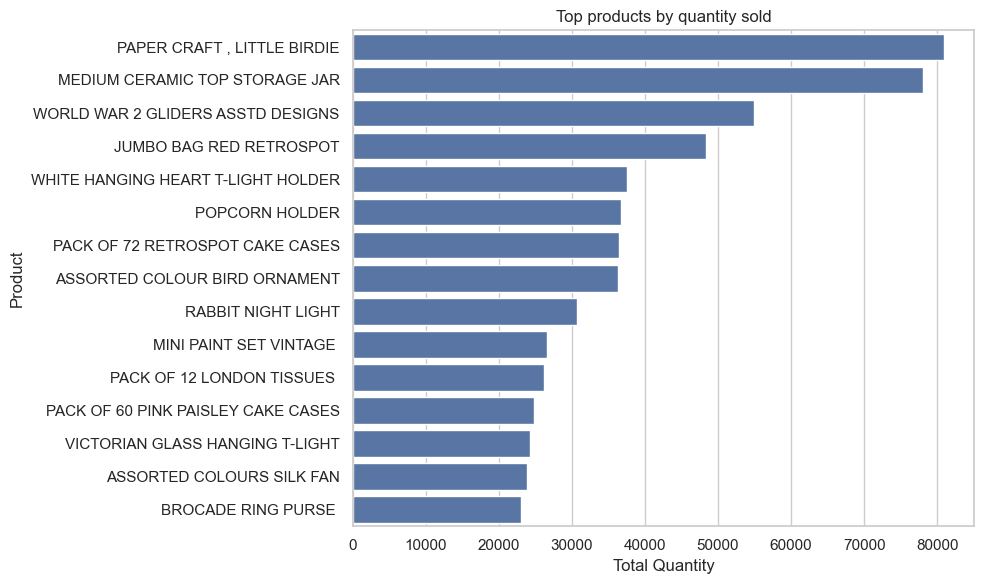

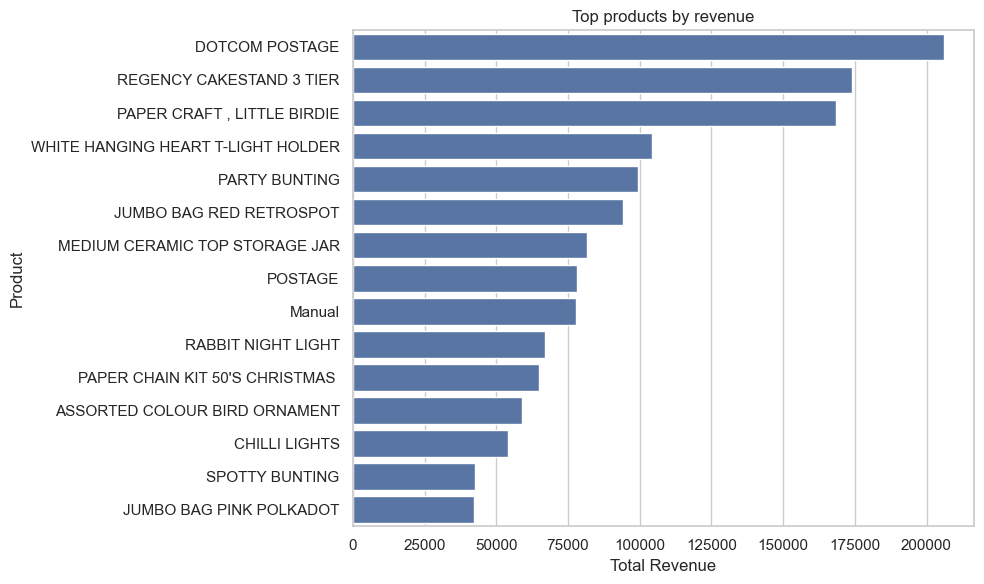

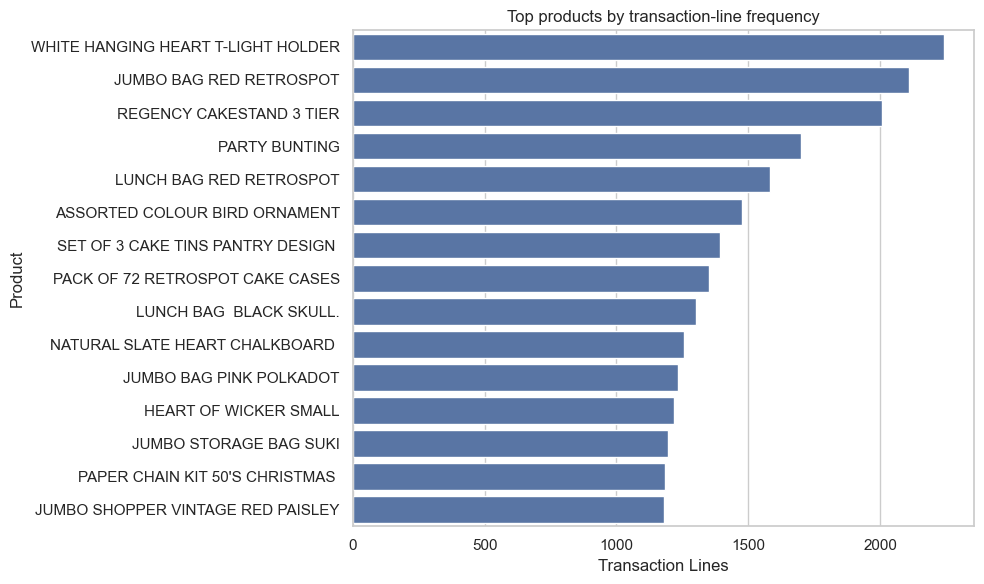

In [10]:
def barplot_top_products(data, value_col, title):
    plot_df = data.copy()
    plot_df["label"] = plot_df["Description"].fillna(plot_df["StockCode"].astype(str)).astype(str).str.slice(0, 45)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=plot_df, x=value_col, y="label")
    plt.title(title)
    plt.xlabel(value_col.replace("_", " ").title())
    plt.ylabel("Product")
    plt.tight_layout()
    plt.show()

barplot_top_products(top_qty, "total_quantity", "Top products by quantity sold")
barplot_top_products(top_revenue, "total_revenue", "Top products by revenue")
barplot_top_products(top_frequency, "transaction_lines", "Top products by transaction-line frequency")


In [11]:
# Products with contrasting quantity and revenue behavior.
product_summary["quantity_rank"] = product_summary["total_quantity"].rank(ascending=False)
product_summary["revenue_rank"] = product_summary["total_revenue"].rank(ascending=False)
product_summary["rank_gap_quantity_minus_revenue"] = product_summary["quantity_rank"] - product_summary["revenue_rank"]

high_revenue_lower_quantity = product_summary.sort_values("rank_gap_quantity_minus_revenue", ascending=False).head(10)
high_quantity_lower_revenue = product_summary.sort_values("rank_gap_quantity_minus_revenue", ascending=True).head(10)

print("High revenue relative to quantity rank:")
display(high_revenue_lower_quantity[["StockCode", "Description", "total_quantity", "total_revenue", "quantity_rank", "revenue_rank"]])

print("High quantity relative to revenue rank:")
display(high_quantity_lower_revenue[["StockCode", "Description", "total_quantity", "total_revenue", "quantity_rank", "revenue_rank"]])


High revenue relative to quantity rank:


,StockCode,Description,total_quantity,total_revenue,quantity_rank,revenue_rank
4140,B,Adjust bad debt,1,"11,062.060","4,116.500",201.000
4139,AMAZONFEE,AMAZON FEE,2,"13,761.090","4,033.000",148.000
1337,22502,PICNIC BASKET WICKER 60 PIECES,61,"39,619.500","3,009.000",17.000
1663,22827,RUSTIC SEVENTEEN DRAWER SIDEBOARD,35,"5,415.000","3,248.500",470.000
1489,22655,VINTAGE RED KITCHEN CABINET,60,"8,125.000","3,020.000",297.000
1490,22656,VINTAGE BLUE KITCHEN CABINET,26,"3,685.000","3,359.000",677.000
1662,22826,LOVE SEAT ANTIQUE WHITE METAL,58,"6,210.000","3,032.000",415.000
1659,22823,CHEST NATURAL WOOD 20 DRAWERS,24,"2,745.000","3,397.500",854.000
1664,22828,REGENCY MIRROR WITH SHUTTERS,10,"1,530.000","3,702.500","1,313.000"
4142,C2,CARRIAGE,142,"7,051.000","2,604.500",351.000


High quantity relative to revenue rank:


,StockCode,Description,total_quantity,total_revenue,quantity_rank,revenue_rank
20,16045,POPART WOODEN PENCILS ASST,8900,380.000,101.000,"2,452.000"
26,16216,LETTER SHAPE PENCIL SHARPENER,3333,234.000,410.000,"2,741.000"
27,16218,CARTOON PENCIL SHARPENERS,3821,283.310,353.000,"2,629.000"
42,18007,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,5884,395.610,205.000,"2,426.000"
35,16259,PIECE OF CAMO STATIONERY SET,3380,326.560,403.000,"2,540.000"
39,17038,PORCELAIN BUDAH INCENSE HOLDER,1525,158.060,931.000,"2,947.000"
11,16008,SMALL FOLDING SCISSOR(POINTED EDGE),2892,360.710,474.000,"2,481.500"
28,16219,HOUSE SHAPE PENCIL SHARPENER,3048,407.720,456.000,"2,411.000"
25,16054,POPART RECT PENCIL SHARPENER ASST,1166,140.520,"1,138.500","3,013.000"
498,21402,RED EGG SPOON,1369,185.520,"1,006.000","2,857.000"


### Interpretation guide

Compare top products by quantity and revenue. A low-priced product may dominate quantity, while a higher-priced product may dominate revenue. Product importance should be linked to the business question rather than a single ranking.


## Customer-level analysis

Customer-level metrics require valid `CustomerID`. Rows without customer identifiers are excluded only for this section, not necessarily for product or country-level summaries.


,CustomerID,total_revenue,number_of_orders,transaction_lines,average_order_value
1689,14646,"280,206.020",73,2076,"3,838.439"
4201,18102,"259,657.300",60,431,"4,327.622"
3728,17450,"194,390.790",46,336,"4,225.887"
3008,16446,"168,472.500",2,3,"84,236.250"
1879,14911,"143,711.170",201,5670,714.981
55,12415,"124,914.530",21,714,"5,948.311"
1333,14156,"117,210.080",55,1395,"2,131.092"
3771,17511,"91,062.380",31,963,"2,937.496"
2702,16029,"80,850.840",63,241,"1,283.347"
0,12346,"77,183.600",1,1,"77,183.600"


,total_revenue,number_of_orders,transaction_lines,average_order_value
count,"4,338.000","4,338.000","4,338.000","4,338.000"
mean,"2,048.688",4.272,90.524,417.646
std,"8,985.230",7.698,225.507,"1,796.511"
min,3.750,1.000,1.000,3.450
25%,306.482,1.000,17.000,177.867
50%,668.570,2.000,41.000,291.940
75%,"1,660.597",5.000,98.000,428.281
max,"280,206.020",209.000,"7,676.000","84,236.250"


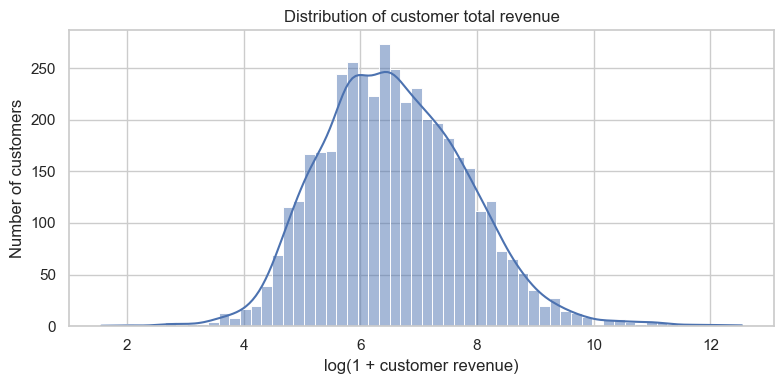

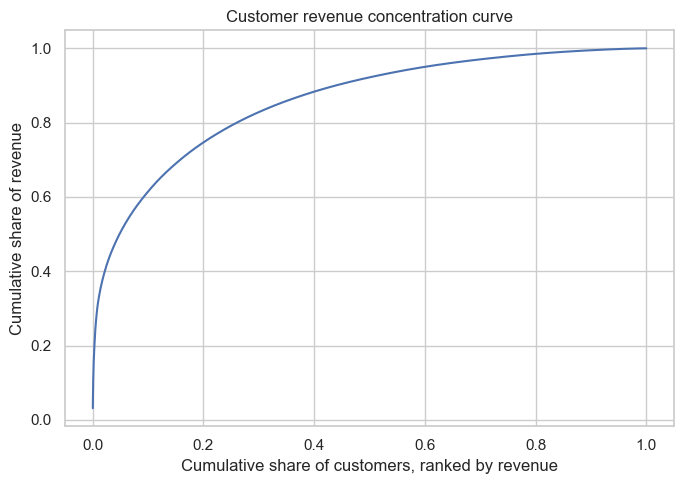

In [12]:
customer_df = clean_df.dropna(subset=["CustomerID"]).copy()
customer_df["CustomerID"] = customer_df["CustomerID"].astype(int).astype(str)

customer_summary = customer_df.groupby("CustomerID").agg(
    total_revenue=("Revenue", "sum"),
    number_of_orders=("InvoiceNo", "nunique"),
    transaction_lines=("InvoiceNo", "count"),
    average_order_value=("Revenue", lambda x: x.sum())
).reset_index()

# Recompute AOV using customer-level total revenue divided by unique invoices.
customer_summary["average_order_value"] = customer_summary["total_revenue"] / customer_summary["number_of_orders"]

display(customer_summary.sort_values("total_revenue", ascending=False).head(10))
display(customer_summary[["total_revenue", "number_of_orders", "transaction_lines", "average_order_value"]].describe())

plt.figure(figsize=(8, 4))
sns.histplot(np.log1p(customer_summary["total_revenue"]), bins=60, kde=True)
plt.title("Distribution of customer total revenue")
plt.xlabel("log(1 + customer revenue)")
plt.ylabel("Number of customers")
plt.tight_layout()
plt.show()

customer_summary_sorted = customer_summary.sort_values("total_revenue", ascending=False).copy()
customer_summary_sorted["cumulative_revenue_share"] = customer_summary_sorted["total_revenue"].cumsum() / customer_summary_sorted["total_revenue"].sum()
customer_summary_sorted["customer_rank_share"] = np.arange(1, len(customer_summary_sorted) + 1) / len(customer_summary_sorted)

plt.figure(figsize=(7, 5))
plt.plot(customer_summary_sorted["customer_rank_share"], customer_summary_sorted["cumulative_revenue_share"])
plt.xlabel("Cumulative share of customers, ranked by revenue")
plt.ylabel("Cumulative share of revenue")
plt.title("Customer revenue concentration curve")
plt.tight_layout()
plt.show()


### Interpretation guide

Check whether revenue is concentrated among a small share of customers. If the concentration curve rises quickly, customer value is highly unequal and segmentation becomes important.


## Country-wise sales analysis

Country-level analysis helps identify whether conclusions are dominated by one market. If one country contributes most records, global summaries may mostly represent that country.


,Country,transaction_lines,unique_invoices,total_revenue,unique_customers
36,United Kingdom,479985,18019,"9,001,744.094",3920
24,Netherlands,2359,94,"285,446.340",9
10,EIRE,7879,288,"283,140.520",3
14,Germany,9025,457,"228,678.400",94
13,France,8392,392,"209,625.370",87
0,Australia,1181,57,"138,453.810",9
31,Spain,2479,90,"61,558.560",30
33,Switzerland,1958,54,"57,067.600",21
3,Belgium,2031,98,"41,196.340",25
32,Sweden,450,36,"38,367.830",8


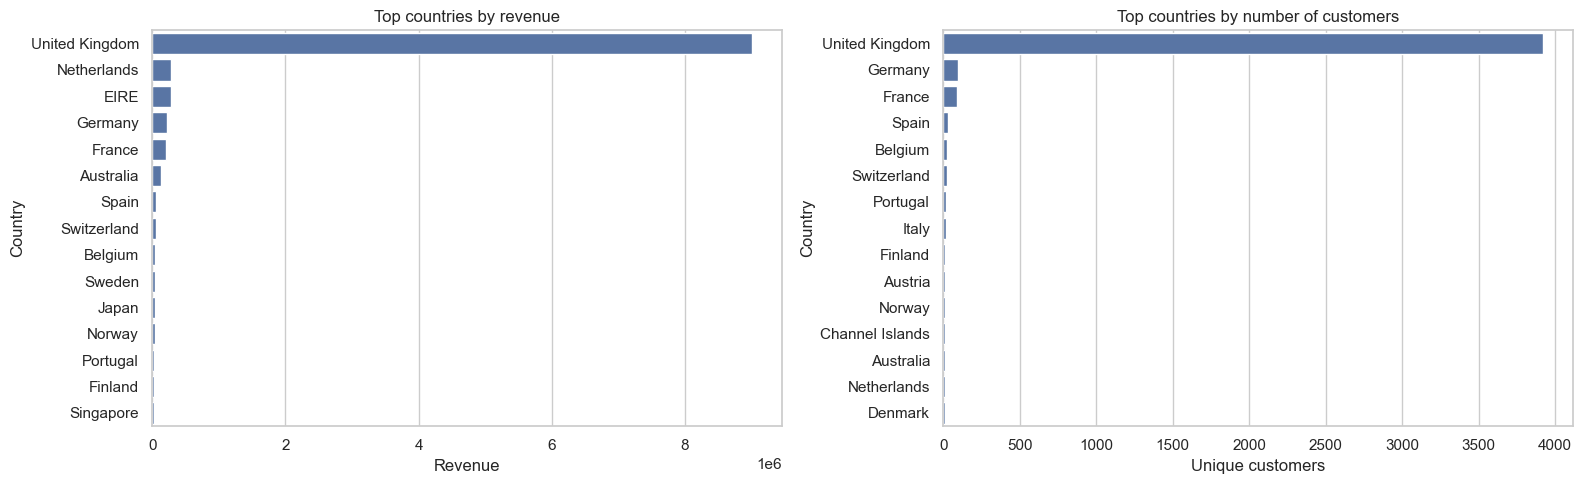

,rows,revenue,invoices
region,,,
Non-UK,44893,"1,640,366.710",1941
UK,479985,"9,001,744.094",18019


In [13]:
country_summary = clean_df.groupby("Country").agg(
    transaction_lines=("InvoiceNo", "count"),
    unique_invoices=("InvoiceNo", "nunique"),
    total_revenue=("Revenue", "sum"),
    unique_customers=("CustomerID", lambda x: x.nunique(dropna=True))
).reset_index().sort_values("total_revenue", ascending=False)

display(country_summary.head(15))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=country_summary.head(15), x="total_revenue", y="Country", ax=axes[0])
axes[0].set_title("Top countries by revenue")
axes[0].set_xlabel("Revenue")
axes[0].set_ylabel("Country")

sns.barplot(data=country_summary.sort_values("unique_customers", ascending=False).head(15), x="unique_customers", y="Country", ax=axes[1])
axes[1].set_title("Top countries by number of customers")
axes[1].set_xlabel("Unique customers")
axes[1].set_ylabel("Country")
plt.tight_layout()
plt.show()

uk_non_uk = clean_df.assign(region=np.where(clean_df["Country"].eq("United Kingdom"), "UK", "Non-UK"))    .groupby("region").agg(rows=("InvoiceNo", "count"), revenue=("Revenue", "sum"), invoices=("InvoiceNo", "nunique"))
display(uk_non_uk)


### Interpretation guide

Compare revenue, invoices, and unique customers by country. If one country dominates, later customer segmentation may mostly reflect that country's purchasing patterns.


## Time-based sales trend

Time features allow monthly, weekly, and hourly patterns to be studied. These patterns can reveal seasonality, operational cycles, and peak ordering periods.


In [14]:
time_df = clean_df.copy()
time_df["InvoiceDate"] = pd.to_datetime(time_df["InvoiceDate"])
time_df["YearMonth"] = time_df["InvoiceDate"].dt.to_period("M").astype(str)
time_df["Date"] = time_df["InvoiceDate"].dt.date
time_df["DayOfWeek"] = time_df["InvoiceDate"].dt.day_name()
time_df["Hour"] = time_df["InvoiceDate"].dt.hour

monthly = time_df.groupby("YearMonth").agg(
    revenue=("Revenue", "sum"),
    invoices=("InvoiceNo", "nunique"),
    transaction_lines=("InvoiceNo", "count")
).reset_index()

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow = time_df.groupby("DayOfWeek").agg(revenue=("Revenue", "sum"), invoices=("InvoiceNo", "nunique")).reindex(day_order).reset_index()
hourly = time_df.groupby("Hour").agg(revenue=("Revenue", "sum"), invoices=("InvoiceNo", "nunique")).reset_index()

display(monthly.head())


,YearMonth,revenue,invoices,transaction_lines
0,2010-12,"821,452.730",1559,40991
1,2011-01,"689,811.610",1086,34060
2,2011-02,"522,545.560",1100,26882
3,2011-03,"716,215.260",1454,35497
4,2011-04,"536,968.491",1246,28882


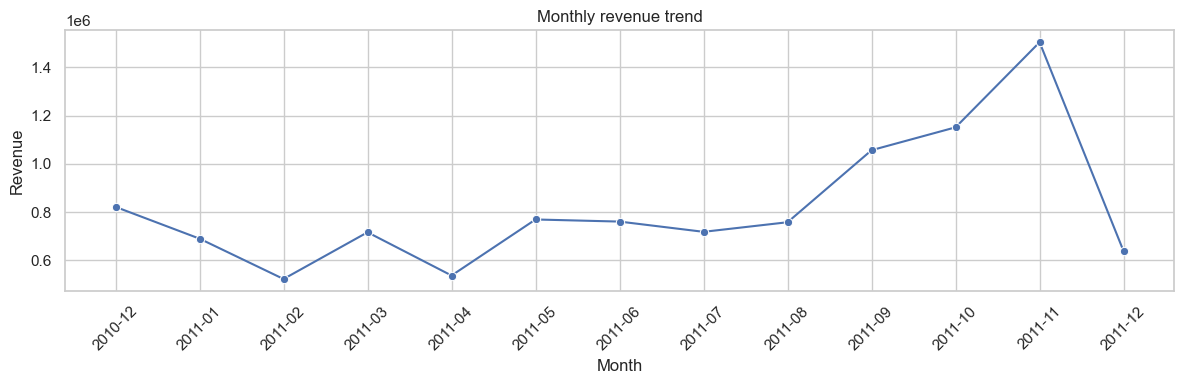

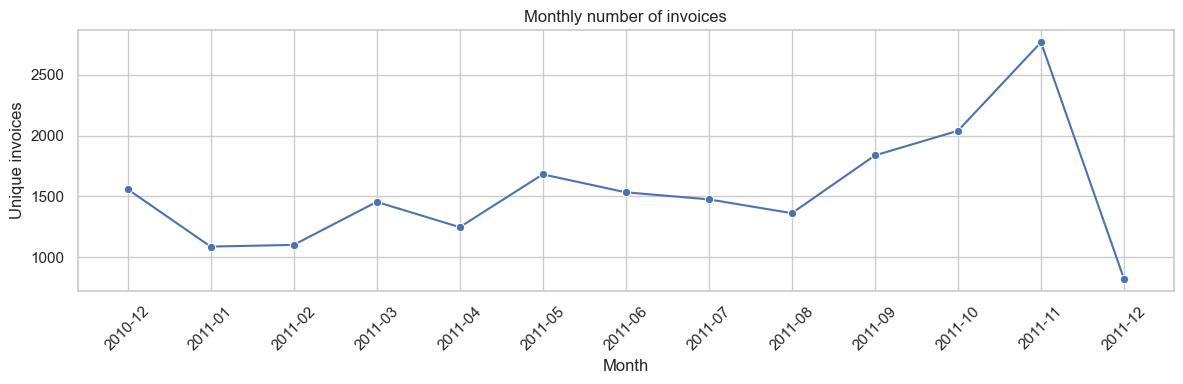

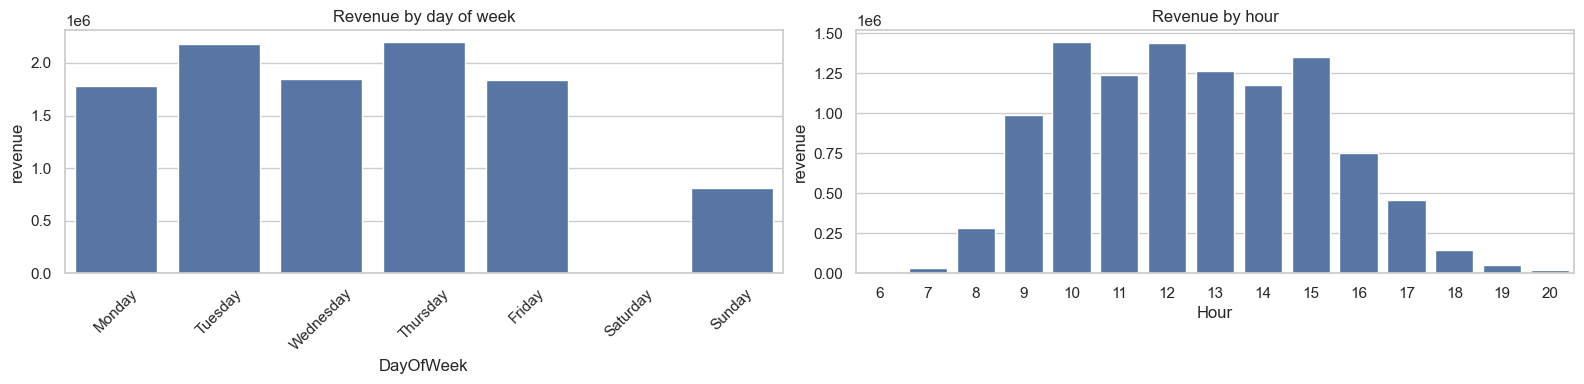

In [15]:
plt.figure(figsize=(12, 4))
sns.lineplot(data=monthly, x="YearMonth", y="revenue", marker="o")
plt.xticks(rotation=45)
plt.title("Monthly revenue trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
sns.lineplot(data=monthly, x="YearMonth", y="invoices", marker="o")
plt.xticks(rotation=45)
plt.title("Monthly number of invoices")
plt.xlabel("Month")
plt.ylabel("Unique invoices")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
sns.barplot(data=dow, x="DayOfWeek", y="revenue", ax=axes[0])
axes[0].tick_params(axis="x", rotation=45)
axes[0].set_title("Revenue by day of week")
sns.barplot(data=hourly, x="Hour", y="revenue", ax=axes[1])
axes[1].set_title("Revenue by hour")
plt.tight_layout()
plt.show()


### Interpretation guide

Inspect whether monthly revenue has seasonal peaks, whether invoice count follows the same pattern as revenue, and whether certain days or hours dominate. A revenue peak without a similar invoice peak may indicate larger order values rather than more orders.


## RFM analysis

RFM converts transaction history into customer-level behavioral features:

- **Recency**: how many days have passed since the customer's last purchase.
- **Frequency**: how many distinct orders the customer placed.
- **Monetary**: how much revenue the customer generated.

These features are simple but widely used because they summarize customer value and engagement.


Snapshot date: 2011-12-10 12:50:00


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,"77,183.600"
1,12347,2,7,"4,310.000"
2,12348,75,4,"1,797.240"
3,12349,19,1,"1,757.550"
4,12350,310,1,334.400


,Recency,Frequency,Monetary
count,"4,338.000","4,338.000","4,338.000"
mean,92.536,4.272,"2,048.688"
std,100.014,7.698,"8,985.230"
min,1.000,1.000,3.750
25%,18.000,1.000,306.482
50%,51.000,2.000,668.570
75%,142.000,5.000,"1,660.597"
max,374.000,209.000,"280,206.020"


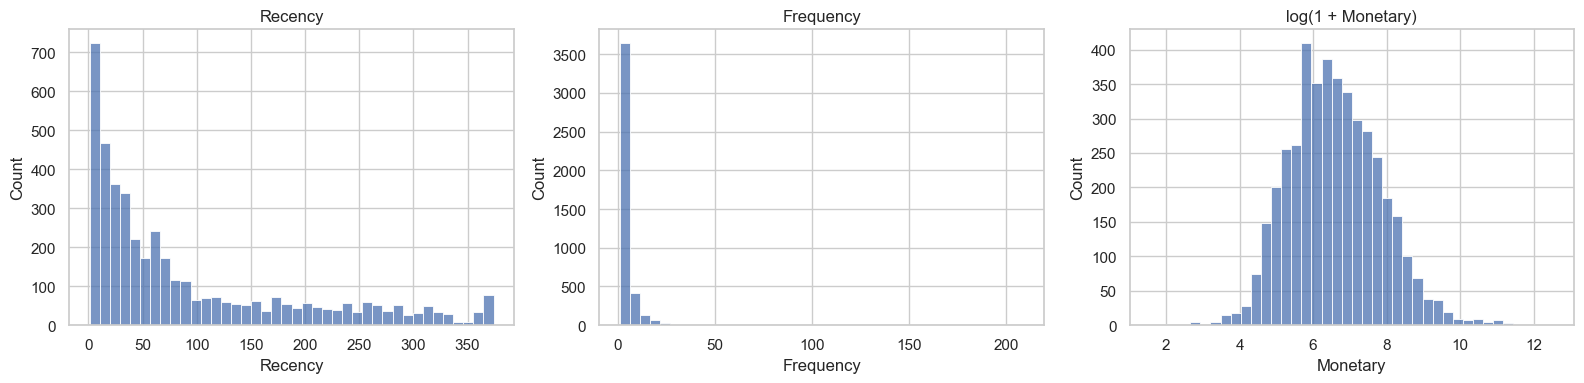

In [16]:
snapshot_date = customer_df["InvoiceDate"].max() + pd.Timedelta(days=1)
print("Snapshot date:", snapshot_date)

rfm = customer_df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("Revenue", "sum")
).reset_index()

display(rfm.head())
display(rfm[["Recency", "Frequency", "Monetary"]].describe())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(rfm["Recency"], bins=40, ax=axes[0])
axes[0].set_title("Recency")
sns.histplot(rfm["Frequency"], bins=40, ax=axes[1])
axes[1].set_title("Frequency")
sns.histplot(np.log1p(rfm["Monetary"]), bins=40, ax=axes[2])
axes[2].set_title("log(1 + Monetary)")
plt.tight_layout()
plt.show()


## RFM scoring and rule-based customer segments

Quantile-based scoring gives each customer a relative rank. For recency, a lower value is better; for frequency and monetary value, higher values are better.

Rule-based segments are intentionally simple. They should be interpreted as business heuristics, not as ground truth labels.


,customers,avg_recency,avg_frequency,avg_monetary,total_monetary
Segment,,,,,
Champions,942,12.503,11.197,"6,091.244","5,737,952.120"
Loyal customers,508,37.207,5.124,"1,826.031","927,623.751"
At risk,661,150.643,3.413,"1,246.464","823,912.441"
Potential loyalists,614,16.950,1.788,890.262,"546,620.670"
Lost customers,1074,216.675,1.101,487.713,"523,803.282"
Low/medium value,539,52.046,1.566,607.229,"327,296.630"


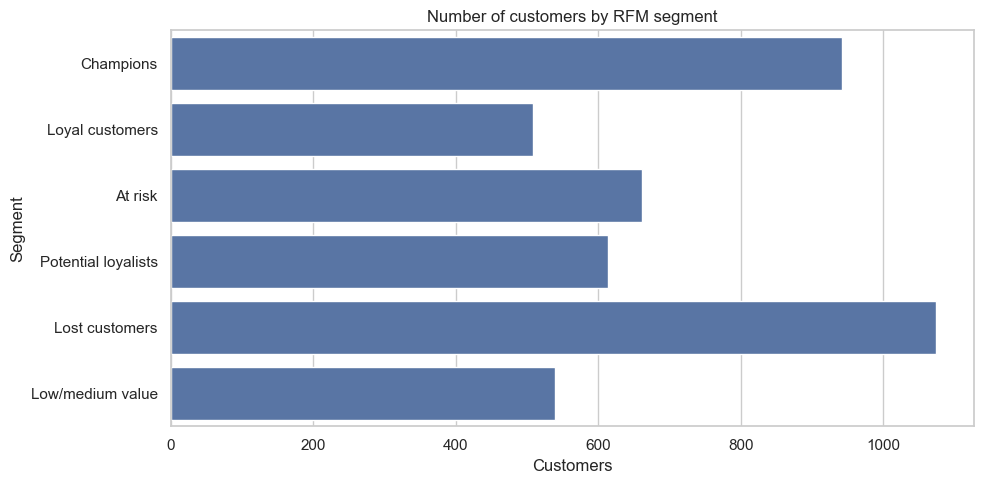

In [17]:
rfm_scored = rfm.copy()

# qcut can fail if there are many tied values, so duplicates="drop" is used.
# Ranking before qcut reduces problems caused by tied values.
# For Recency, lower days are better, so the labels are reversed.
rfm_scored["R_score"] = pd.qcut(rfm_scored["Recency"].rank(method="first"), q=5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm_scored["F_score"] = pd.qcut(rfm_scored["Frequency"].rank(method="first"), q=5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm_scored["M_score"] = pd.qcut(rfm_scored["Monetary"].rank(method="first"), q=5, labels=[1, 2, 3, 4, 5]).astype(int)

rfm_scored["RFM_score"] = rfm_scored[["R_score", "F_score", "M_score"]].sum(axis=1)

def assign_segment(row):
    if row["R_score"] >= 4 and row["F_score"] >= 4 and row["M_score"] >= 4:
        return "Champions"
    if row["R_score"] >= 3 and row["F_score"] >= 4:
        return "Loyal customers"
    if row["R_score"] >= 4 and row["F_score"] <= 3:
        return "Potential loyalists"
    if row["R_score"] <= 2 and row["F_score"] >= 3:
        return "At risk"
    if row["R_score"] <= 2 and row["F_score"] <= 2:
        return "Lost customers"
    return "Low/medium value"

rfm_scored["Segment"] = rfm_scored.apply(assign_segment, axis=1)

segment_summary = rfm_scored.groupby("Segment").agg(
    customers=("CustomerID", "count"),
    avg_recency=("Recency", "mean"),
    avg_frequency=("Frequency", "mean"),
    avg_monetary=("Monetary", "mean"),
    total_monetary=("Monetary", "sum")
).sort_values("total_monetary", ascending=False)

display(segment_summary)

plt.figure(figsize=(10, 5))
sns.barplot(data=segment_summary.reset_index(), x="customers", y="Segment")
plt.title("Number of customers by RFM segment")
plt.xlabel("Customers")
plt.ylabel("Segment")
plt.tight_layout()
plt.show()


### Interpretation guide

Compare segment sizes and monetary contribution. A small segment may still contribute high revenue. Segment names should be checked against the actual recency, frequency, and monetary summaries before being used for business decisions.


## Optional: customer segmentation using K-Means

K-Means provides an unsupervised alternative to rule-based segmentation. Because RFM variables are skewed and have different scales, log transformation and standardization are applied before clustering.

The number of clusters is not a fact in the data; it is a modeling choice that should be evaluated using metrics and interpretability.


,k,inertia,silhouette
0,2,"6,483.589",0.433
1,3,"4,869.489",0.337
2,4,"3,939.049",0.338
3,5,"3,296.709",0.316
4,6,"2,855.764",0.312
5,7,"2,548.820",0.309


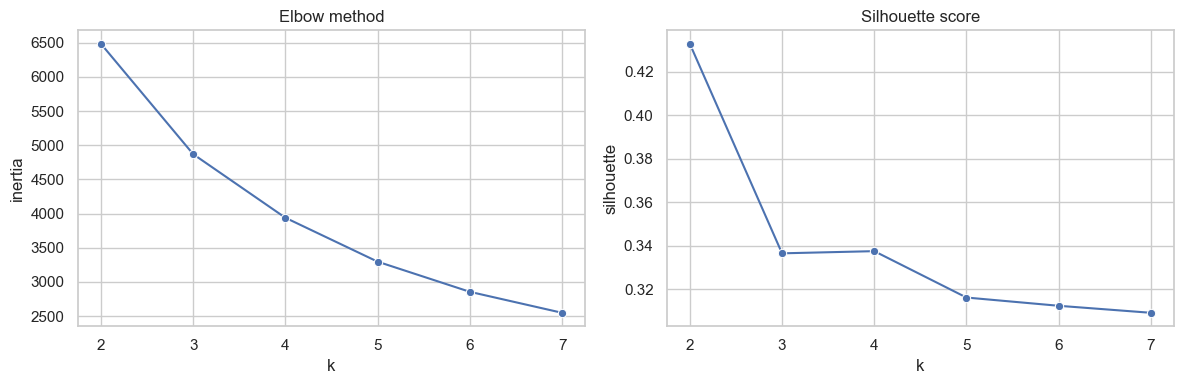

In [18]:
rfm_features = rfm[["Recency", "Frequency", "Monetary"]].copy()
rfm_log = np.log1p(rfm_features)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

cluster_scores = []
for k in range(2, 8):
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = model.fit_predict(rfm_scaled)
    inertia = model.inertia_
    silhouette = silhouette_score(rfm_scaled, labels)
    cluster_scores.append({"k": k, "inertia": inertia, "silhouette": silhouette})

cluster_scores_df = pd.DataFrame(cluster_scores)
display(cluster_scores_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.lineplot(data=cluster_scores_df, x="k", y="inertia", marker="o", ax=axes[0])
axes[0].set_title("Elbow method")
sns.lineplot(data=cluster_scores_df, x="k", y="silhouette", marker="o", ax=axes[1])
axes[1].set_title("Silhouette score")
plt.tight_layout()
plt.show()


,customers,avg_recency,avg_frequency,avg_monetary,total_monetary
Cluster,,,,,
0,713,12.171,13.752,"8,088.018","5,766,757.070"
3,1166,71.636,4.079,"1,801.778","2,100,873.023"
2,837,17.699,2.192,557.323,"466,479.030"
1,1622,181.507,1.317,340.999,"553,099.771"


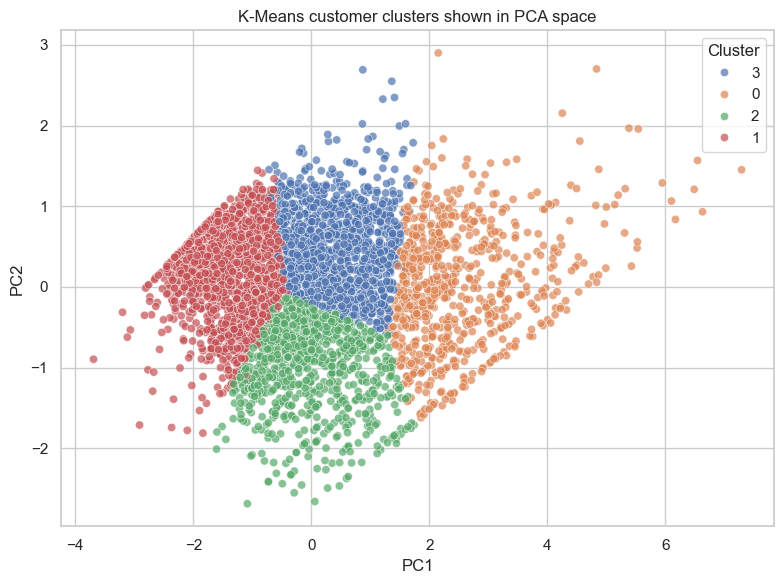

In [19]:
# Choose a moderate number of clusters for demonstration.
# After execution, this can be changed based on the elbow/silhouette plots and interpretability.
K = 4
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10)
rfm_clustered = rfm.copy()
rfm_clustered["Cluster"] = kmeans.fit_predict(rfm_scaled)

cluster_profile = rfm_clustered.groupby("Cluster").agg(
    customers=("CustomerID", "count"),
    avg_recency=("Recency", "mean"),
    avg_frequency=("Frequency", "mean"),
    avg_monetary=("Monetary", "mean"),
    total_monetary=("Monetary", "sum")
).sort_values("avg_monetary", ascending=False)

display(cluster_profile)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_coords = pca.fit_transform(rfm_scaled)
plot_clusters = pd.DataFrame({"PC1": pca_coords[:, 0], "PC2": pca_coords[:, 1], "Cluster": rfm_clustered["Cluster"].astype(str)})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_clusters, x="PC1", y="PC2", hue="Cluster", alpha=0.7)
plt.title("K-Means customer clusters shown in PCA space")
plt.tight_layout()
plt.show()


### Interpretation guide

Review the cluster profile table before naming clusters. A cluster with low recency, high frequency, and high monetary value may represent valuable active customers. A cluster with high recency and low frequency may represent inactive or low-engagement customers. The PCA plot is only a two-dimensional projection, so cluster overlap in the plot does not always mean the clusters are invalid.


## Evaluation and validation of EDA conclusions

EDA does not have a single accuracy score, but its conclusions can still be checked:

- Compare summaries before and after cleaning.
- Check whether outliers are valid transactions or data errors.
- Verify that customer-level analysis excludes missing `CustomerID` values.
- Compare product rankings by quantity, revenue, and frequency instead of relying on one metric.
- Test whether customer segments are stable under different scoring rules or cluster counts.
- Ask whether the conclusions are plausible for the business context.


In [20]:
eda_validation_summary = pd.DataFrame({
    "check": [
        "Rows retained after sales cleaning",
        "CustomerID coverage in cleaned data",
        "Revenue from top 10 customers",
        "Revenue from UK transactions",
        "Number of RFM customers"
    ],
    "value": [
        f"{len(clean_df):,} of {len(df):,}",
        f"{100 * clean_df['CustomerID'].notna().mean():.2f}%",
        f"{100 * customer_summary.sort_values('total_revenue', ascending=False).head(10)['total_revenue'].sum() / customer_summary['total_revenue'].sum():.2f}% of customer-identifiable revenue",
        f"{100 * clean_df.loc[clean_df['Country'].eq('United Kingdom'), 'Revenue'].sum() / clean_df['Revenue'].sum():.2f}% of cleaned revenue",
        f"{len(rfm):,} customers"
    ]
})
display(eda_validation_summary)


,check,value
0,Rows retained after sales cleaning,"524,878 of 541,909"
1,CustomerID coverage in cleaned data,74.82%
2,Revenue from top 10 customers,17.30% of customer-identifiable revenue
3,Revenue from UK transactions,84.59% of cleaned revenue
4,Number of RFM customers,"4,338 customers"


## Run-specific analytical notes

The previous tables and plots contain many details. The following cell converts the main executed results into a compact analytical summary. This is useful for the README, report writing, or a final discussion section after the notebook is run.

In [21]:

from IPython.display import Markdown, display

def money_fmt(x):
    return f"{x:,.2f}"

def pct_fmt(x):
    return f"{100*x:.2f}%"

clean_share = len(clean_df) / len(df)
customer_id_coverage = clean_df["CustomerID"].notna().mean()
total_revenue = clean_df["Revenue"].sum()

top_revenue_product = product_summary.sort_values("total_revenue", ascending=False).iloc[0]
top_quantity_product = product_summary.sort_values("total_quantity", ascending=False).iloc[0]
top_country = country_summary.sort_values("total_revenue", ascending=False).iloc[0]
country_revenue_share = top_country["total_revenue"] / country_summary["total_revenue"].sum()

top10_customer_share = (
    customer_summary.sort_values("total_revenue", ascending=False)
    .head(10)["total_revenue"].sum()
    / customer_summary["total_revenue"].sum()
)

peak_month = monthly.sort_values("revenue", ascending=False).iloc[0]
peak_hour = hourly.sort_values("revenue", ascending=False).iloc[0]
peak_day = dow.sort_values("revenue", ascending=False).iloc[0]

top_segment = segment_summary.sort_values("total_monetary", ascending=False).iloc[0]
largest_segment = segment_summary.sort_values("customers", ascending=False).iloc[0]

best_k_row = cluster_scores_df.sort_values("silhouette", ascending=False).iloc[0]
top_cluster = cluster_profile.sort_values("avg_monetary", ascending=False).iloc[0]

notes = f"""
### Analytical summary from the executed run

- **Cleaning impact:** the positive-sales dataset keeps **{len(clean_df):,} rows out of {len(df):,} raw rows** ({pct_fmt(clean_share)}). Any revenue or customer conclusion in this notebook therefore refers to cleaned positive sales, not gross transaction activity including cancellations.
- **Customer identification:** **{pct_fmt(customer_id_coverage)}** of cleaned rows have a valid `CustomerID`. Product and country analysis can use all cleaned rows, but customer/RFM analysis is based only on identifiable customers.
- **Revenue concentration:** the top 10 customers contribute **{pct_fmt(top10_customer_share)}** of identifiable customer revenue. This is a strong reason to move beyond average-customer analysis and examine high-value segments separately.
- **Product ranking difference:** the highest-revenue product is **{top_revenue_product['Description']}**, while the highest-quantity product is **{top_quantity_product['Description']}**. This confirms that quantity ranking and revenue ranking answer different business questions.
- **Country concentration:** **{top_country['Country']}** is the largest revenue country, contributing **{pct_fmt(country_revenue_share)}** of cleaned revenue. If this share is very high, global conclusions may mostly reflect this dominant market.
- **Temporal pattern:** the peak revenue month is **{peak_month['YearMonth']}**, the peak revenue day is **{peak_day['DayOfWeek']}**, and the peak revenue hour is **{int(peak_hour['Hour'])}:00**. These should be checked against invoice counts to separate more orders from larger orders.
- **RFM interpretation:** the highest-revenue rule-based segment is **{top_segment.name}**, while the largest segment by customer count is **{largest_segment.name}**. A segment with fewer customers can still be strategically important if its monetary contribution is high.
- **K-Means check:** the highest silhouette score among the tested values occurs at **k = {int(best_k_row['k'])}**, while the demonstration clustering used **k = {K}**. If these differ, prefer the cluster count that balances metric quality and interpretability.
- **Cluster profile:** the cluster with the highest average monetary value is cluster **{int(top_cluster.name)}**. Its recency and frequency values should be checked before giving it a business label such as “high value”, “recent loyal”, or “inactive high spender”.
"""

display(Markdown(notes))



### Analytical summary from the executed run

- **Cleaning impact:** the positive-sales dataset keeps **524,878 rows out of 541,909 raw rows** (96.86%). Any revenue or customer conclusion in this notebook therefore refers to cleaned positive sales, not gross transaction activity including cancellations.
- **Customer identification:** **74.82%** of cleaned rows have a valid `CustomerID`. Product and country analysis can use all cleaned rows, but customer/RFM analysis is based only on identifiable customers.
- **Revenue concentration:** the top 10 customers contribute **17.30%** of identifiable customer revenue. This is a strong reason to move beyond average-customer analysis and examine high-value segments separately.
- **Product ranking difference:** the highest-revenue product is **DOTCOM POSTAGE**, while the highest-quantity product is **PAPER CRAFT , LITTLE BIRDIE**. This confirms that quantity ranking and revenue ranking answer different business questions.
- **Country concentration:** **United Kingdom** is the largest revenue country, contributing **84.59%** of cleaned revenue. If this share is very high, global conclusions may mostly reflect this dominant market.
- **Temporal pattern:** the peak revenue month is **2011-11**, the peak revenue day is **Thursday**, and the peak revenue hour is **10:00**. These should be checked against invoice counts to separate more orders from larger orders.
- **RFM interpretation:** the highest-revenue rule-based segment is **Champions**, while the largest segment by customer count is **Lost customers**. A segment with fewer customers can still be strategically important if its monetary contribution is high.
- **K-Means check:** the highest silhouette score among the tested values occurs at **k = 2**, while the demonstration clustering used **k = 4**. If these differ, prefer the cluster count that balances metric quality and interpretability.
- **Cluster profile:** the cluster with the highest average monetary value is cluster **0**. Its recency and frequency values should be checked before giving it a business label such as “high value”, “recent loyal”, or “inactive high spender”.


## Limitations

- The dataset comes from one business and one time period.
- Missing `CustomerID` values limit customer-level analysis.
- Cancellations and returns are removed for positive-sales analysis, but a full business analysis may need net revenue treatment.
- Revenue is not profit because cost and margin data are unavailable.
- Product category metadata is absent, so product-level insights are based on item descriptions and stock codes.
- Customer demographics and marketing exposure are unavailable.
- RFM and K-Means segments are descriptive; they do not prove future customer behavior.


## What we learned

- Raw transaction data needs cleaning before business interpretation.
- Missing values affect which questions can be answered reliably.
- Product importance depends on whether quantity, revenue, or frequency is used.
- Customer revenue is often concentrated, making customer-level analysis important.
- RFM analysis converts transaction records into interpretable customer intelligence.
- Clustering can support segmentation, but cluster labels require business interpretation.
- EDA should be treated as a structured reasoning process, not only a collection of plots.


## Possible extensions

- Market basket analysis using association rules.
- Customer lifetime value prediction.
- Churn or inactivity prediction.
- Product recommendation systems.
- Cohort analysis by first purchase month.
- Demand forecasting using time-series models.
- Return/cancellation behavior modeling.
- Profit-aware analysis if cost and margin data are available.
